# PROYEK  Procurement Dashboard

Saya membuat analisis data pengadaan dengan dataset simulasi. Analisis mencakup nilai pembelian, efisiensi biaya, TKDN, serta status pengiriman dan pembayaran. Proyek ini meniru pekerjaan asli seorang procurement data officer.

Tujuan: Membuat analisis data procurement berisi:

Nilai pembelian

Efisiensi biaya (cost saving)

TKDN

Status pemenuhan pesanan

Visualisasi (grafik)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

n = 400

vendors = ["PT Sumber Makmur", "PT Maju Jaya", "PT Globalindo", "PT Sinar Abadi"]
categories = ["Material", "Sparepart", "Chemical", "Jasa"]
status_delivery = ["delivered", "pending", "late"]
status_payment = ["paid", "unpaid"]

data = {
    "purchase_id": range(1, n+1),
    "vendor": np.random.choice(vendors, n),
    "category": np.random.choice(categories, n),
    "quote_price": np.random.randint(10_000_000, 200_000_000, n),
    "deal_price": np.random.randint(8_000_000, 180_000_000, n),
    "local_component": np.random.randint(2_000_000, 100_000_000, n),
    "import_component": np.random.randint(1_000_000, 80_000_000, n),
    "order_date": pd.date_range("2024-01-01", periods=n, freq="D"),
    "delivery_status": np.random.choice(status_delivery, n),
    "payment_status": np.random.choice(status_payment, n)
}

df = pd.DataFrame(data)

# Hitung TKDN
df["TKDN"] = df["local_component"] / (df["local_component"] + df["import_component"]) * 100

# Hitung cost saving
df["cost_saving"] = df["quote_price"] - df["deal_price"]

df.head()


,purchase_id,vendor,category,quote_price,deal_price,local_component,import_component,order_date,delivery_status,payment_status,TKDN,cost_saving
0,1,PT Globalindo,Jasa,184478184,140960449,67564145,26554414,2024-01-01,delivered,paid,71.786208,43517735
1,2,PT Sinar Abadi,Jasa,21720477,158481610,80021860,27931806,2024-01-02,late,paid,74.126116,-136761133
2,3,PT Sumber Makmur,Chemical,128338832,47138695,12047595,14476005,2024-01-03,pending,unpaid,45.422171,81200137
3,4,PT Globalindo,Material,157435376,176016921,32908587,45721695,2024-01-04,delivered,paid,41.852307,-18581545
4,5,PT Globalindo,Jasa,32558781,136759218,97112669,4151882,2024-01-05,late,paid,95.899965,-104200437


# Nilai pembelian

In [2]:
total_purchase = df["deal_price"].sum()
print("Total Nilai Pembelian:", total_purchase)


Total Nilai Pembelian: 39908471862


# Rata-rata TKDN

In [10]:
avg_tkdn = df["TKDN"].mean()
print("Rata-rata TKDN:", avg_tkdn)


Rata-rata TKDN: 52.925633004969185


# Efisiensi biaya

In [11]:
total_saving = df["cost_saving"].sum()
print("Total Cost Saving:", total_saving)


Total Cost Saving: 2715822985


# Distribusi status pemenuhan pesanan

In [5]:
df["delivery_status"].value_counts()


,count
delivery_status,
pending,142
delivered,139
late,119


# Grafik Nilai Pembelian per Vendor

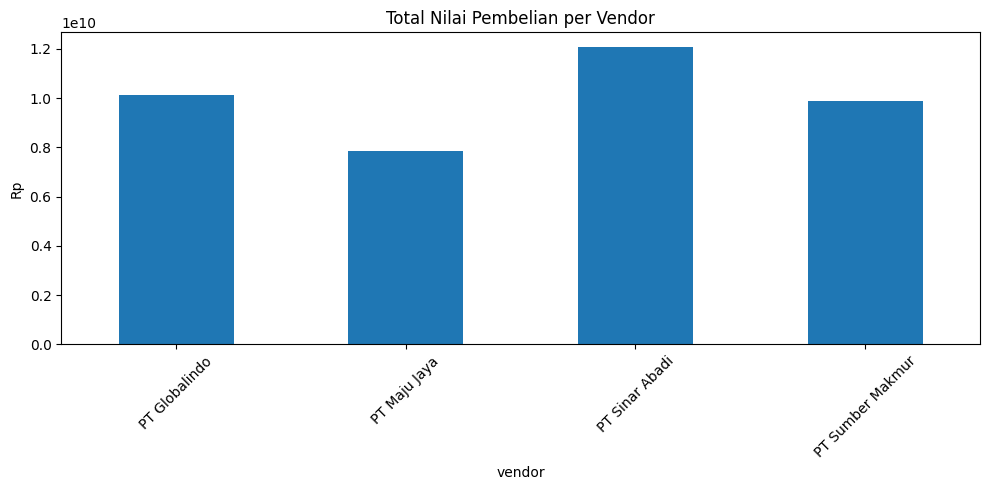

In [6]:
vendor_purchase = df.groupby("vendor")["deal_price"].sum()

plt.figure(figsize=(10,5))
vendor_purchase.plot(kind="bar")
plt.title("Total Nilai Pembelian per Vendor")
plt.ylabel("Rp")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


PT Sinar Abadi memiliki total nilai pembelian tertinggi, sehingga merupakan vendor dengan kontribusi terbesar dalam total spending.PT Nusantara Sejahtera memiliki nilai pembelian paling kecil.

Perbandingan antar vendor sangat jelas sehingga dapat membantu dalam:
evaluasi konsolidasi vendor,prioritas negosiasi harga,manajemen risiko (ketergantungan pada vendor tertentu).

# Grafik Cost Saving per Vendor

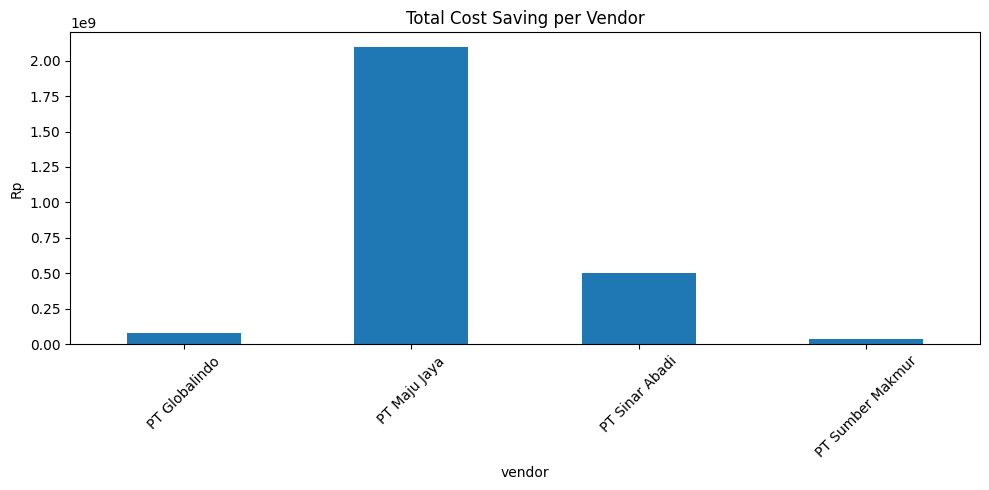

In [7]:
vendor_saving = df.groupby("vendor")["cost_saving"].sum()

plt.figure(figsize=(10,5))
vendor_saving.plot(kind="bar")
plt.title("Total Cost Saving per Vendor")
plt.ylabel("Rp")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


PT Maju Jaya memberikan cost saving terbesar, menunjukkan vendor ini lebih fleksibel dalam negosiasi atau memiliki margin harga yang besar.

PT Nusantara Sejahtera memberikan cost saving terendah.

Perbedaan antar vendor dapat digunakan untuk:
 menentukan vendor yang paling efisien,
 memilih vendor prioritas untuk kontrak jangka panjang,
 membuat strategi negosiasi harga ke depannya.

# Distribusi TKDN

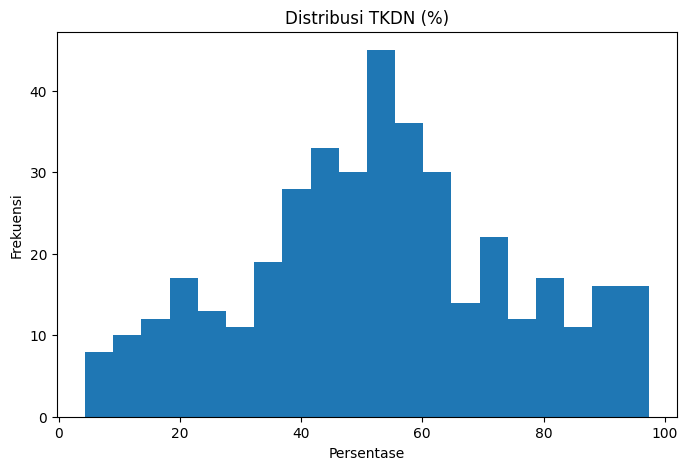

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["TKDN"], bins=20)
plt.title("Distribusi TKDN (%)")
plt.xlabel("Persentase")
plt.ylabel("Frekuensi")
plt.show()


Mayoritas data berada di tengah (40%–60%), menandakan banyak produk dengan kandungan lokal menengah.

Beberapa nilai rendah (<20%) menunjukkan masih ada ketergantungan pada barang impor.

Nilai tinggi (>80%) menandakan adanya produk dengan kandungan lokal yang besar.

# Status Pengiriman

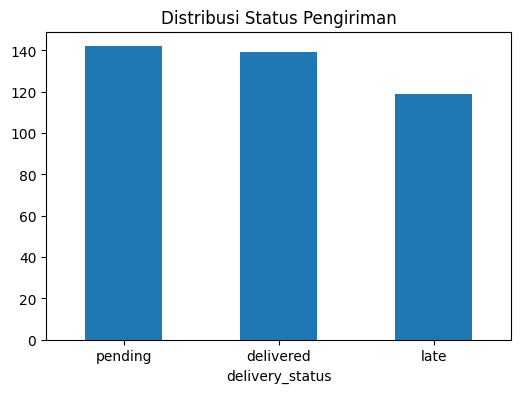

In [9]:
plt.figure(figsize=(6,4))
df["delivery_status"].value_counts().plot(kind="bar")
plt.title("Distribusi Status Pengiriman")
plt.xticks(rotation=0)
plt.show()


Sebagian besar pengiriman berstatus Delivered, menandakan performa logistik vendor cukup baik.

Masih ada status Pending dalam jumlah tertentu → perlu monitoring.

Terdapat status Late, yang menjadi perhatian khusus karena berpotensi mengganggu operasional.